# Arsenic Contamination Example

In [1]:
import random
import math
import numpy as np
from epyt_flow.simulation import ScenarioSimulator, EpanetConstants


def create_random_contamination_event(time_window: tuple[int, int],
                                      duration_interval: tuple[int, int], n_time_steps: int):
    """Create a random contamination event profile for three contaminants:
    - Pathogen (P)
    - Carbon Fraction Rapidly Available (C_FRA)
    - Carbon Slowly Readily Available (C_SRA)
    The contamination event is defined by a random start time within the given time window
    and a random duration within the given duration interval.
    Args:
        time_window (tuple[int, int]): Time window (in time steps) within which the contamination event can start.
        duration_interval (tuple[int, int]): Duration interval (in time steps) for the contamination event.
        n_time_steps (int): Total number of time steps in the simulation.
    Returns:
        tuple: Three tuples, each containing the species ID and its corresponding contamination profile (mass injected at each time step).
    """
    # Random point in time
    start_time = random.randint(time_window[0], time_window[1])

    # Random duration
    end_time = start_time + random.randint(duration_interval[0], duration_interval[1])
    
    print("start end", start_time, end_time)

    # Random amount of contaminants (no need to change these values)
    EV_log_min = math.log10(1.39e6)
    EV_log_max = math.log10(2.08e7)
    EV_conc = 10 ** (EV_log_min + random.uniform(0, 1) * (EV_log_max - EV_log_min))
    TOC = 140 + random.uniform(0, 1) * (250 - 140)
    C_FRA_fraction = 0.4
    C_SRA_fraction = 0.6

    rate = 10000000000 # injection intensity

    injection_conc_P = EV_conc * rate 

    injection_conc_C_FRA = C_FRA_fraction * TOC * rate
    injection_conc_C_SRA = C_SRA_fraction * TOC * rate
    print(injection_conc_P, injection_conc_C_FRA, injection_conc_C_SRA)

    # Initialize profiles with zeros (no contamination at the beginning)
    # Then add the contamination event for the corresponding time steps

    profile_P = np.zeros(n_time_steps)
    profile_P[start_time:end_time] = injection_conc_P 

    profile_C_FRA = np.zeros(n_time_steps)
    profile_C_FRA[start_time:end_time] = injection_conc_C_FRA

    profile_C_SRA = np.zeros(n_time_steps)
    profile_C_SRA[start_time:end_time] = injection_conc_C_SRA

    # return lists of values for each time step, for each species that correspond to what we will inject at each time step, for each species
    return ("P", profile_P), ("C_FRA", profile_C_FRA), ("C_SRA", profile_C_SRA)


In [ ]:
f_inp_in = "CY-DBP_competition_stream_competition_6days_0.inp"  #inp file for topology and hydraulics
f_msx_in = "CY-DBP_competition_stream_competition_6days_0.msx" # msx file for water quality and species
# f_inp_in = "CY-DBP_competition_stream_competition_365days.inp"   
# f_msx_in = "CY-DBP_competition_stream_competition_365days.msx"

########################################################################
# Parameters of the contamination events
duration_interval = (60, 480)    # Duration interval of the contamination event in minutes 
n_contamination_events = 4  # Number of contamination events to generate
time_window = (3, 5)        # Event can start between day 3 and day 6
#n_contamination_events = 5  # Alternative: multiple events over the year
#time_window = (5, 350)      # Event can start between day 6 and day 350
########################################################################

In [3]:
scenario = ScenarioSimulator(f_inp_in=f_inp_in, f_msx_in=f_msx_in)

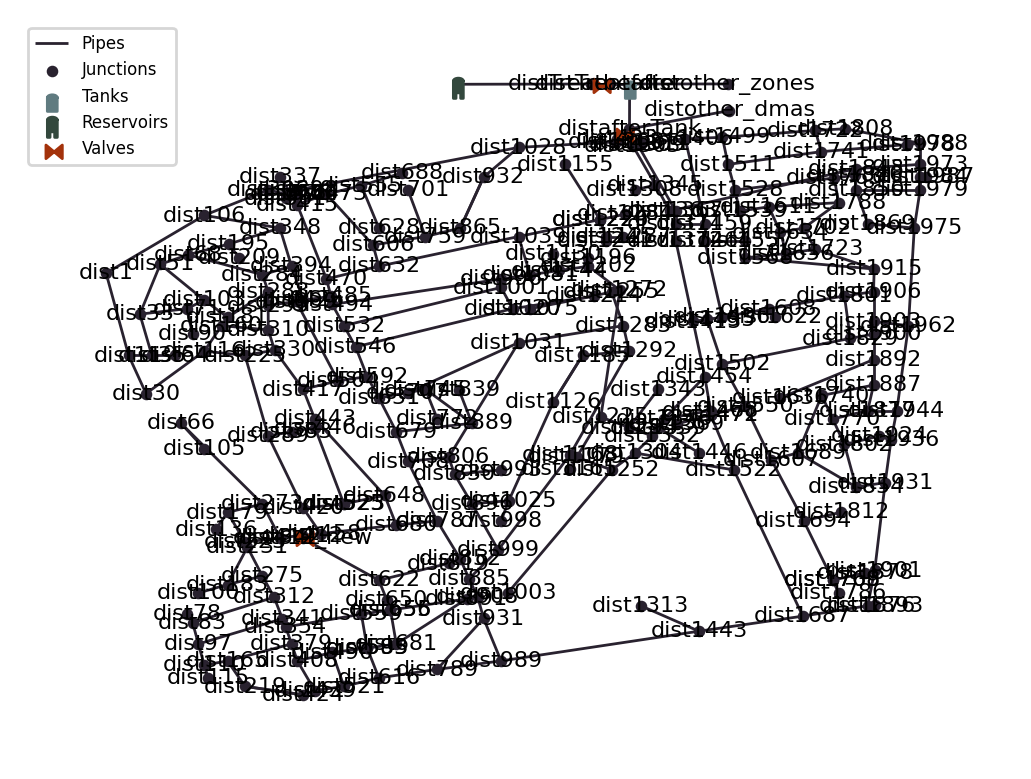

In [4]:
from epyt_flow.visualization import ScenarioVisualizer
vis = ScenarioVisualizer(scenario)
vis.add_labels(['nodes'])
vis.show_plot()

In [5]:
topo = scenario.get_topology()

print(topo.nodes)
print(topo.edges)


['distTreatbefore', 'distTreatafter', 'distafterTank', 'dist1', 'dist11', 'dist30', 'dist33', 'dist35', 'dist51', 'dist64', 'dist66', 'dist68', 'dist71', 'dist78', 'dist83', 'dist90', 'dist97', 'dist100', 'dist103', 'dist105', 'dist106', 'dist110', 'dist115', 'dist116', 'dist136', 'dist160', 'dist165', 'dist179', 'dist181', 'dist183', 'dist195', 'dist209', 'dist219', 'dist223', 'dist225', 'dist231', 'dist273', 'dist275', 'dist284', 'dist288', 'dist289', 'dist295', 'dist306', 'dist310', 'dist312', 'dist330', 'dist337', 'dist341', 'dist342', 'dist348', 'dist354', 'dist356', 'dist361', 'dist376', 'dist379', 'dist383', 'dist394', 'dist398', 'dist399', 'dist406', 'dist408', 'dist412', 'dist412_new', 'dist415', 'dist417', 'dist420', 'dist423', 'dist424', 'dist426', 'dist439', 'dist443', 'dist446', 'dist458', 'dist470', 'dist473', 'dist485', 'dist490', 'dist494', 'dist504', 'dist521', 'dist523', 'dist525', 'dist532', 'dist546', 'dist555', 'dist559', 'dist585', 'dist592', 'dist593', 'dist606',

In [6]:
# Show information associated with node "dist1308"
print(topo.get_node_info("dist1308"))

{'elevation': 57.223899841308594, 'coord': [950.0, 1190.0], 'comment': 'NULL', 'type': 0, 'base_demand': 0.14945699274539948}


Set simulation duration to 21 days by calling [set_general_parameters()](https://epyt-flow.readthedocs.io/en/stable/epyt_flow.simulation.html#epyt_flow.simulation.scenario_simulator.ScenarioSimulator.set_general_parameters) -- note that all time durations have to be stated in seconds, the function [to_seconds()](https://epyt-flow.readthedocs.io/en/stable/epyt_flow.html#epyt_flow.utils.to_seconds) can convert minutes/hours/days to seconds:

In [7]:
# scenario.set_general_parameters(simulation_duration=to_seconds(days=50))

In [8]:
# Setup time intervals
hyd_time_step = scenario.get_hydraulic_time_step()  # Usually 5min time steps (so 5*60 seconds )
steps_per_day = (24 * 60 * 60) / hyd_time_step
time_window = (time_window[0] * steps_per_day, time_window[1] * steps_per_day) 
duration_interval = ((duration_interval[0] * 60) / hyd_time_step,
                        (duration_interval[1] * 60) / hyd_time_step)
n_time_steps = int(scenario.get_simulation_duration() / hyd_time_step)

# Add random contamination events
all_junctions = scenario.get_topology().get_all_junctions() # get all nodes in the network
contamination_patterns = [] 
node_id = "dist35"
for _ in range(n_contamination_events):
    print(f"Injecting contamination at node {node_id}")
    contaminants_profiles = create_random_contamination_event(time_window, duration_interval,
                                                                n_time_steps) # get contamination profiles for each species
    print(time_window, duration_interval, n_time_steps)
    for species_id, pattern in contaminants_profiles:
        contamination_patterns.append(pattern) # pattern is the list of values at each time step for each species
        scenario.add_species_injection_source(species_id, node_id, pattern, 
                                                EpanetConstants.EN_MASS) # inject contamination into the node following the profile
    node_id = random.choice(all_junctions) # select a random node

    


Injecting contamination at node dist35
start end 9522 9603
3.877211092328689e+16 850218278324.4086 1275327417486.6125
(1440.0, 100800.0) (12.0, 96.0) 105120
Injecting contamination at node dist525
start end 97671 97723
1.6324238790776716e+16 907312715581.6272 1360969073372.4407
(1440.0, 100800.0) (12.0, 96.0) 105120
Injecting contamination at node dist30
start end 50258 50273
1.0375454903786501e+17 887334287206.3285 1331001430809.4924
(1440.0, 100800.0) (12.0, 96.0) 105120
Injecting contamination at node dist1802
start end 3036 3103
8.83270100368815e+16 907606299845.7043 1361409449768.5562
(1440.0, 100800.0) (12.0, 96.0) 105120


In [9]:
# Compute labels for each time step
# 1 if a contamination present, 0 otherwise
y = np.sum(contamination_patterns, axis=0) != 0
print(y.shape)  # TODO: Export 
# number of time steps with contamination
print(f"Number of time steps with contamination: {np.sum(y)} out of {len(y)}")
# start time steps of contamination events
for i in range(1, len(y)):
    if y[i] != 0 and y[i-1] == 0:
        print(f"Contamination event starts at time step {i}")

(105120,)
Number of time steps with contamination: 215 out of 105120
Contamination event starts at time step 3036
Contamination event starts at time step 9522
Contamination event starts at time step 50258
Contamination event starts at time step 97671


In [10]:
# TEST: run simulation
# Place sensors at all nodes 
scenario.place_bulk_species_node_sensors_everywhere(["P", "CL2", "C_FRA","C_SRA" ]) # Measure of pathogen and chlorine. Chlorine is used as a proxy to detect contamination 
# Run hydraulic and water quality simulation
scada_data = scenario.run_simulation(verbose=True) 


Running EPANET ...


Time steps: 100%|#########9| 105120/105121 [04:12<00:00, 415.75it/s]


Running EPANET-MSX ...


Time steps: 100%|#########9| 105120/105121 [13:54<00:00, 125.98it/s]
c:\Users\eline\Documents\Documents\university\Master 2\memoire\AI-for-Drinking-Water\env\Lib\site-packages\epyt_flow\simulation\scenario_simulator.py:2978: UserWarning: Failed to remove temporary file 'C:\Users\eline\AppData\Local\Temp\epytflow_MSX_68473e79-8aa7-41bf-983d-8b00fd8f65d8.hyd'
  warnings.warn(f"Failed to remove temporary file '{hyd_export}'")


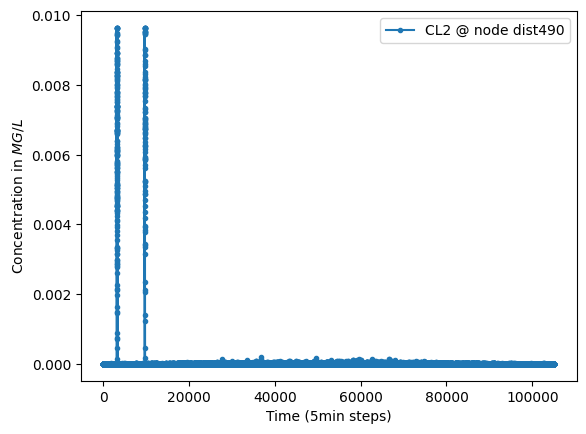

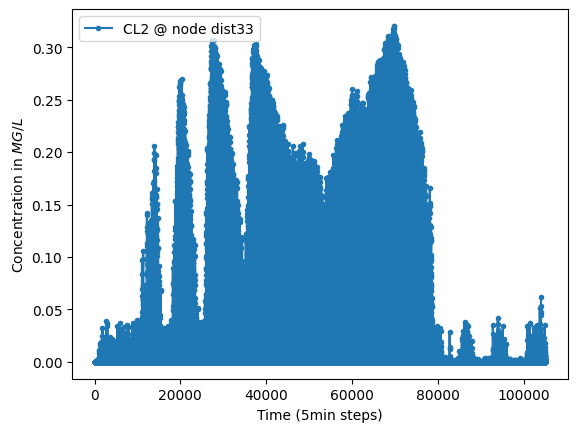

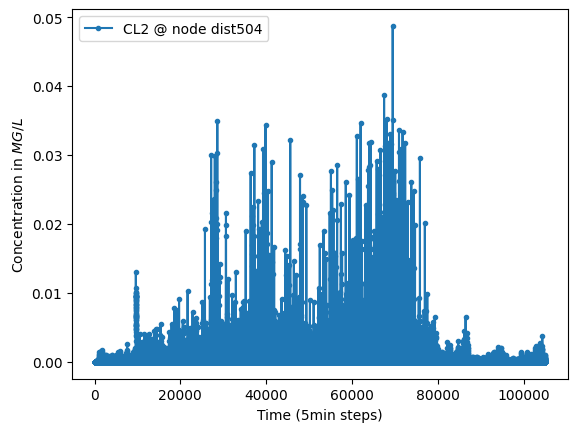

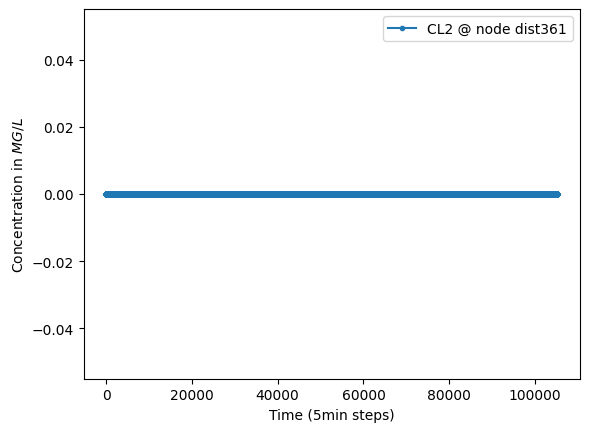

<Axes: xlabel='Time (5min steps)', ylabel='Concentration in $MG/L$'>

In [11]:
# Plot chlorine concentration at a specific node   
# scada_data.plot_bulk_species_node_concentration({"CL2": ["dist71"]}) 
scada_data.plot_bulk_species_node_concentration({"CL2": [node_id]})
scada_data.plot_bulk_species_node_concentration({"CL2": ["dist33"]}) 
scada_data.plot_bulk_species_node_concentration({"CL2": ["dist504"]}) 
scada_data.plot_bulk_species_node_concentration({"CL2": ["dist361"]}) 

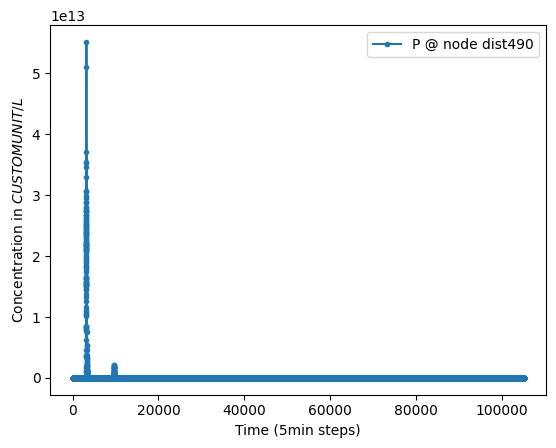

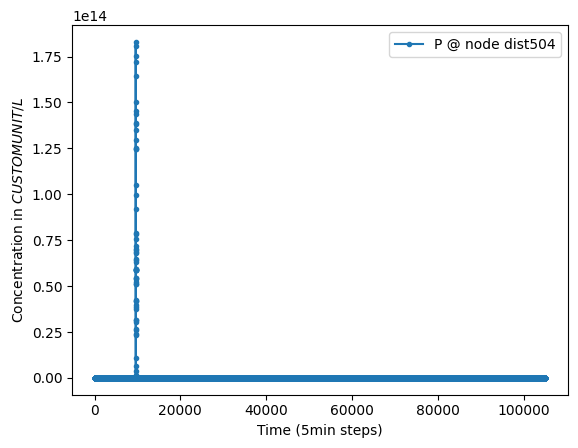

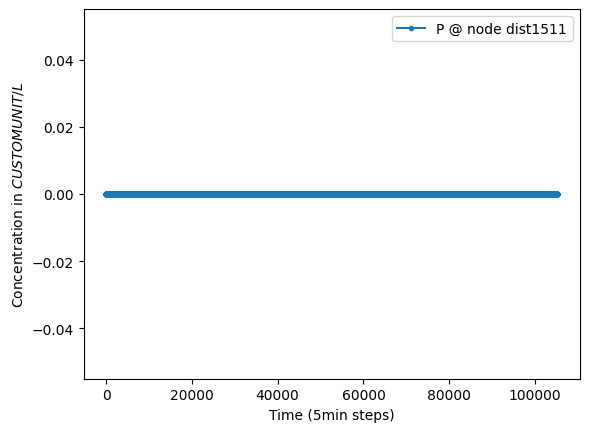

<Axes: xlabel='Time (5min steps)', ylabel='Concentration in $CUSTOM UNIT/L$'>

In [12]:
scada_data.plot_bulk_species_node_concentration({"P": [node_id]}) 
scada_data.plot_bulk_species_node_concentration({"P": ["dist504"]}) 
scada_data.plot_bulk_species_node_concentration({"P": ["dist1511"]}) 

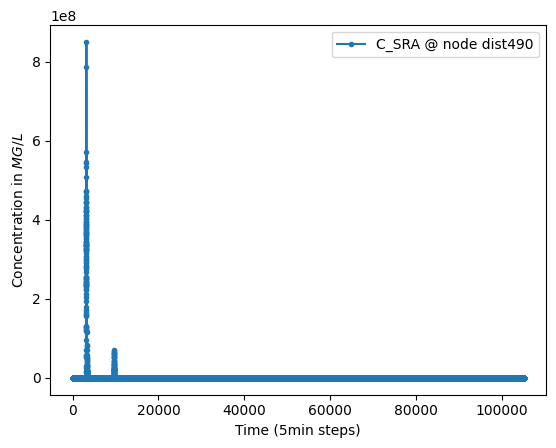

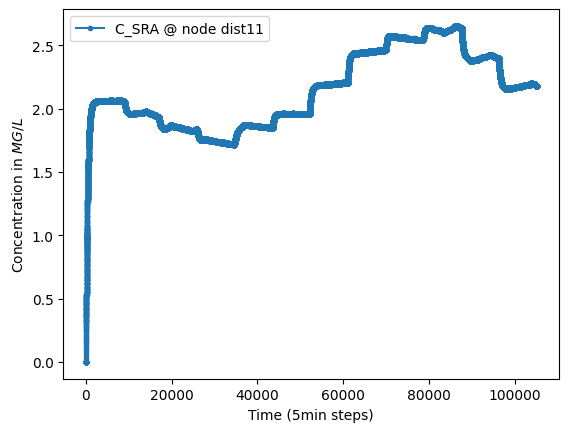

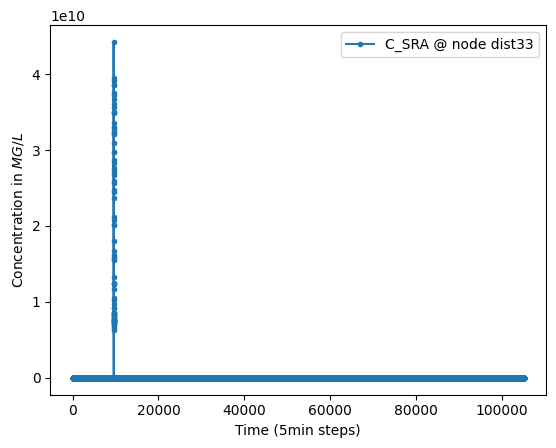

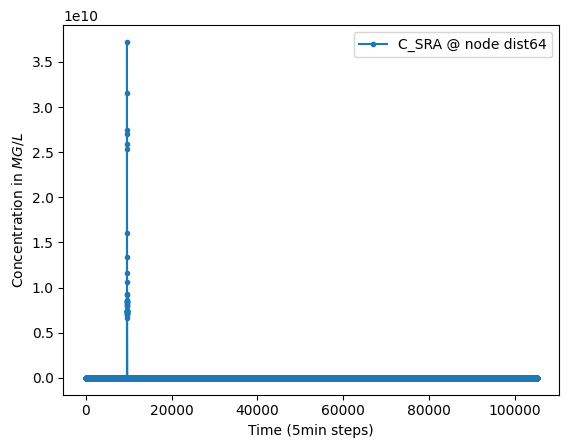

<Axes: xlabel='Time (5min steps)', ylabel='Concentration in $MG/L$'>

In [13]:
scada_data.plot_bulk_species_node_concentration({"C_SRA": [node_id]})
scada_data.plot_bulk_species_node_concentration({"C_SRA": ["dist11"]}) 
scada_data.plot_bulk_species_node_concentration({"C_SRA": ["dist33"]}) 
scada_data.plot_bulk_species_node_concentration({"C_SRA": ["dist64"]}) 

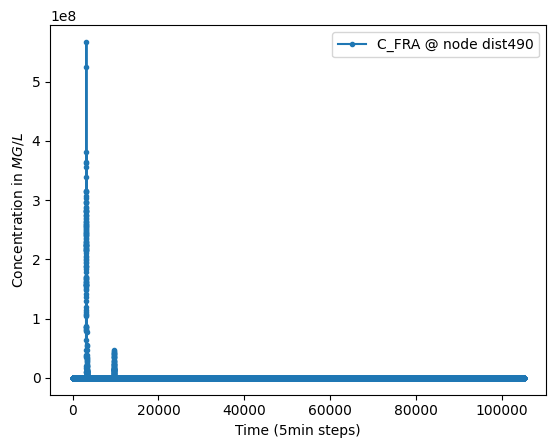

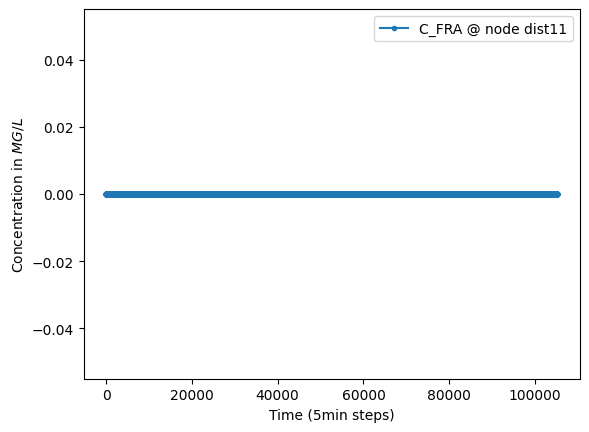

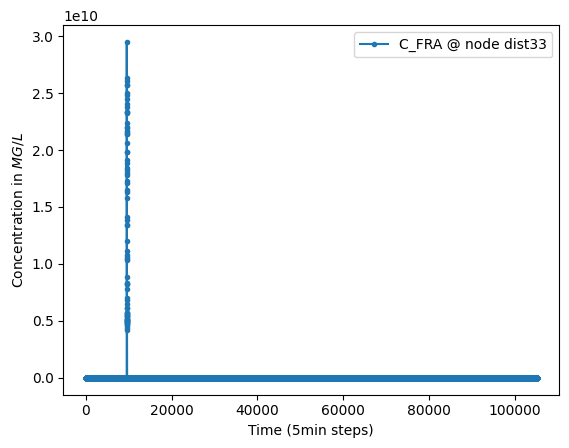

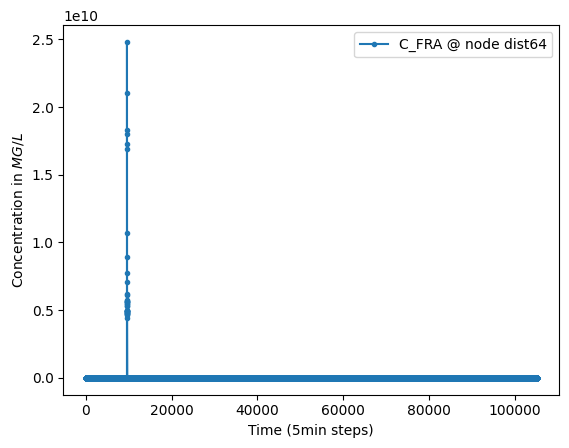

<Axes: xlabel='Time (5min steps)', ylabel='Concentration in $MG/L$'>

In [14]:
scada_data.plot_bulk_species_node_concentration({"C_FRA": [node_id]})
scada_data.plot_bulk_species_node_concentration({"C_FRA": ["dist11"]}) 
scada_data.plot_bulk_species_node_concentration({"C_FRA": ["dist33"]}) 
scada_data.plot_bulk_species_node_concentration({"C_FRA": ["dist64"]}) 

In [15]:
# Export SCADA results 
# scada_data.to_numpy_file("scada_data.npz", export_raw_data=False)
# df = scada_data.to_pandas_dataframe(export_raw_data=False)
df = scada_data.to_pandas_dataframe(export_raw_data=False)
df.to_csv("scada_data.csv", index=False)

Do not forget to close the simulation by calling [close()](https://epyt-flow.readthedocs.io/en/stable/epyt_flow.simulation.html#epyt_flow.simulation.scenario_simulator.ScenarioSimulator.close):

In [16]:
scenario.close()